Loaded Q table from artifacts/q_agent.npz
Saved Q table to artifacts/q_agent.npz
Saved last episode traces to artifacts/q_last_episode.npz


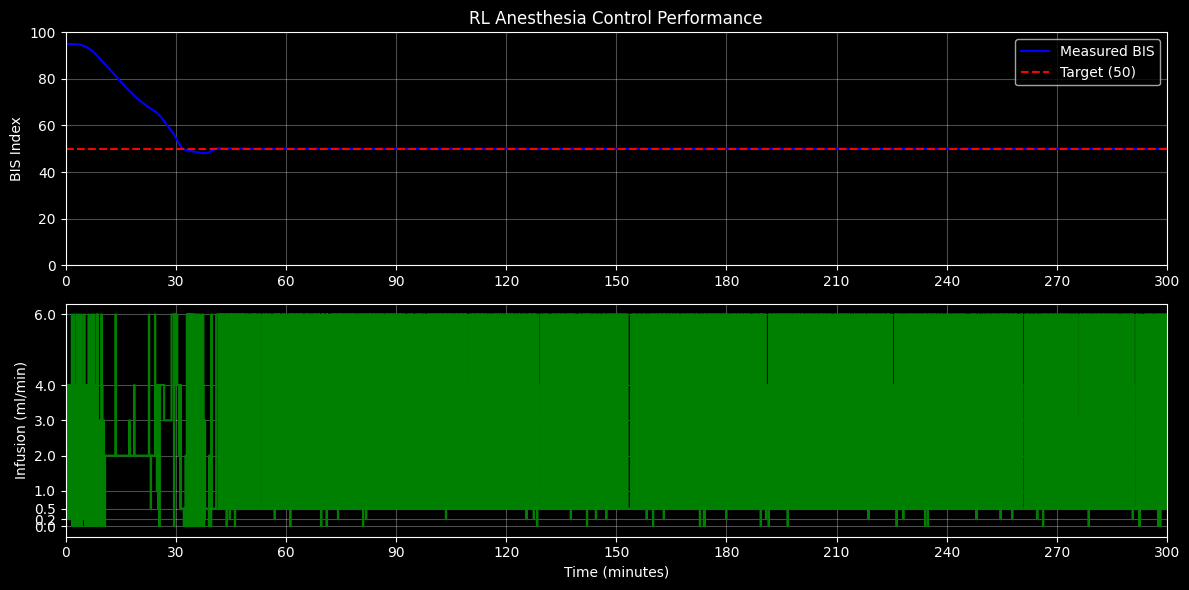

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- MODIFIABLE PARAMETERS ---
TARGET_BIS = 50.0
EPISODES = 5000
STEPS_PER_EP = 3600  # 10 minutes (5s steps)
ALPHA = 0.2         # Learning rate
GAMMA = 0.69        # Discount factor
EPSILON = 0.05      # Exploration

# --- SCHNIDER PK/PD CONSTANTS ---
V1, ke0 = 4.27, 0.17
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5
ACTIONS = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]

# --- ARTIFACT PERSISTENCE ---
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
Q_PATH = ARTIFACTS_DIR / "q_agent.npz"
TRACE_PATH = ARTIFACTS_DIR / "q_last_episode.npz"

def get_state(error, delta):
    """Mappe inputs to discrete state using fuzzy logic scales [10, 11]"""
    # Scale: Error/20, Delta/10. Convert 3-func membership to index
    f1 = np.clip((error + 20) / 40, 0, 0.99)
    f2 = np.clip((delta + 10) / 20, 0, 0.99)
    return int(f1 * 10) * 10 + int(f2 * 10)

# --- LOAD OR INITIALIZE Q TABLE ---
if Q_PATH.exists():
    q_data = np.load(Q_PATH)
    Q = q_data["Q"]
    print(f"Loaded Q table from {Q_PATH}")
else:
    Q = np.zeros((100, len(ACTIONS)))
    print("Initialized new Q table")
bis_history = []
action_history = []

for ep in range(EPISODES):
    c1, c2, c3, ce = 0.0, 0.0, 0.0, 0.0
    err, prev_err = (BIS_0 - TARGET_BIS), (BIS_0 - TARGET_BIS)

    for t in range(STEPS_PER_EP):
        s = get_state(err, err - prev_err)

        # Epsilon-greedy selection
        a_idx = np.random.randint(len(ACTIONS)) if np.random.rand() < EPSILON else np.argmax(Q[s])
        u = ACTIONS[a_idx]

        # Update PK/PD (Euler 5s step) [12, 13]
        dt = 5/60
        c1 += (u - (k10 + k12 + k13)*c1 + k21*c2 + k31*c3) / V1 * dt
        c2 += (k12*c1 - k21*c2) * dt
        c3 += (k13*c1 - k31*c3) * dt
        ce += ke0 * (c1 - ce) * dt

        bis = BIS_0 - BIS_MAX * (ce**HILL / (ce**HILL + EC50**HILL))
        next_err = bis - TARGET_BIS
        reward = -abs(next_err) # [14]

        # Q-Learning update [15]
        s_next = get_state(next_err, next_err - err)
        Q[s, a_idx] += ALPHA * (reward + GAMMA * np.max(Q[s_next]) - Q[s, a_idx])

        if ep == EPISODES - 1: # Log only the last episode for plotting
            bis_history.append(bis)
            action_history.append(u)

        prev_err, err = err, next_err

# --- SAVE TRAINED Q TABLE AND TRACES ---
np.savez_compressed(
    Q_PATH,
    Q=Q,
    actions=np.array(ACTIONS, dtype=float),
    target_bis=np.array([TARGET_BIS], dtype=float),
    alpha=np.array([ALPHA], dtype=float),
    gamma=np.array([GAMMA], dtype=float),
    epsilon=np.array([EPSILON], dtype=float),
)
np.savez_compressed(
    TRACE_PATH,
    bis_history=np.array(bis_history, dtype=float),
    action_history=np.array(action_history, dtype=float),
)
print(f"Saved Q table to {Q_PATH}")
print(f"Saved last episode traces to {TRACE_PATH}")

# --- PLOTTING (NO MANIM) [1, 2] ---
plt.figure(figsize=(12, 6))

# Convert step indices to time (minutes)
if len(bis_history) > 0:
    t_sec = np.arange(len(bis_history)) * 5            # seconds
    t_min = t_sec / 60.0                               # minutes
else:
    t_min = np.array([])

max_min = (STEPS_PER_EP * 5) / 60.0
# choose a reasonable tick spacing: aim for ~8-12 ticks across the x axis
approx_ticks = 10
tick_step = max(1, int(np.ceil(max_min / approx_ticks)))
xticks = np.arange(0, max_min + 1e-8, tick_step)

# Top: BIS levels (plot vs minutes)
plt.subplot(2, 1, 1)
plt.plot(t_min, bis_history, label="Measured BIS", color="blue")
plt.axhline(TARGET_BIS, color="red", linestyle="--", label=f"Target ({TARGET_BIS:.0f})")
plt.ylabel("BIS Index")
plt.title("RL Anesthesia Control Performance")
plt.ylim(0, 100)
plt.xlim(0, max_min)
plt.xticks(xticks)
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom: Infusion rates (plot vs minutes)
plt.subplot(2, 1, 2)
plt.step(t_min, action_history, color="green", where="post")
plt.ylabel("Infusion (ml/min)")
plt.xlabel("Time (minutes)")
plt.xlim(0, max_min)
# Show ticks on y for available discrete action values
plt.yticks(ACTIONS)
plt.xticks(xticks)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()